# ● Problem Statement

Retail businesses generate a large amount of sales data every day, but identifying sales trends, seasonal demand, and future business performance from this data can be challenging. Without accurate forecasting, companies may face problems such as overstocking, stock shortages, inefficient inventory management, and poor business planning.

The objective of this project is to analyze historical retail sales data, understand customer purchasing patterns, and build machine learning and time series forecasting models to predict future sales. The project also aims to identify sales anomalies, cluster products based on their performance, and provide interactive visualizations through a Streamlit dashboard.

By applying techniques such as Exploratory Data Analysis (EDA), Time Series Analysis, Forecasting Models, Anomaly Detection, and Product Clustering, the project helps businesses make data-driven decisions, improve inventory planning, optimize resource allocation, and increase overall profitability.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

# Task 1 — Data Loading, Merging & Deep Exploration

In [53]:
# Load the Superstore Sales CSV using Pandas
df = pd.read_csv("train.csv")

In [54]:
# Display the first 10 rows 
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
5,6,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600
6,7,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800
7,8,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520
8,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
9,10,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000


In [55]:
# Display dataset information including data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [56]:
# Generate descriptive statistics for numerical columns
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [57]:
# Display the number of rows and columns in the dataset
df.shape

(9800, 18)

In [59]:
# Parse the Order Date and Ship Date columns as proper datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [60]:
# To check whether changes have taken place or not
print(df.dtypes)

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code             float64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
dtype: object


In [62]:
# Check for missing values
print("\n--- NULL COUNT ---")
print(df.isnull().sum())


--- NULL COUNT ---
Row ID              0
Order ID            0
Order Date       5841
Ship Date        5985
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code        11
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
dtype: int64


In [10]:
# Extract year from Order Date
df["Year"] = df["Order Date"].dt.year
# Extract month number
df["Month"] = df["Order Date"].dt.month

# Extract month name
df["Month Name"] = df["Order Date"].dt.month_name()

# Extract week number
df["Week"] = df["Order Date"].dt.isocalendar().week

# Extract weekday name
df["Day"] = df["Order Date"].dt.day_name()

# Extract quarter of the year
df["Quarter"] = df["Order Date"].dt.quarter

# Create a custom season column based on month
def season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

# Apply season function to Month column
df["Season"] = df["Month"].apply(season)

In [11]:
# Display updated dataset
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017.0,8.0,August,32,Friday,3.0,Summer
1,2,CA-2017-152156,2017-08-11,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017.0,8.0,August,32,Friday,3.0,Summer
2,3,CA-2017-138688,2017-12-06,NaT,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017.0,12.0,December,49,Wednesday,4.0,Winter
3,4,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016.0,11.0,November,45,Thursday,4.0,Autumn
4,5,US-2016-108966,2016-11-10,NaT,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016.0,11.0,November,45,Thursday,4.0,Autumn
5,6,CA-2015-115812,2015-09-06,NaT,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,2015.0,9.0,September,36,Sunday,3.0,Autumn
6,7,CA-2015-115812,2015-09-06,NaT,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Art,Newell 322,7.2800,2015.0,9.0,September,36,Sunday,3.0,Autumn
7,8,CA-2015-115812,2015-09-06,NaT,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,2015.0,9.0,September,36,Sunday,3.0,Autumn
8,9,CA-2015-115812,2015-09-06,NaT,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,2015.0,9.0,September,36,Sunday,3.0,Autumn
9,10,CA-2015-115812,2015-09-06,NaT,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,2015.0,9.0,September,36,Sunday,3.0,Autumn


In [12]:
# Check for Duplicates
df.duplicated().sum()

np.int64(0)

## ● Weekly Sales Aggregation

In [13]:
# Calculate total sales for each week
weekly_sales = df.groupby(
    pd.Grouper(key="Order Date", freq="W")
)["Sales"].sum()

In [14]:
# Display first 10 weekly sales records
weekly_sales.head(10)

Order Date
2015-01-04     2791.939
2015-01-11    11129.834
2015-01-18     5624.390
2015-01-25        0.000
2015-02-01        0.000
2015-02-08     3928.522
2015-02-15     7750.472
2015-02-22        0.000
2015-03-01       16.448
2015-03-08     2524.790
Name: Sales, dtype: float64

## ● Monthly Sales Aggregation

In [15]:
# Calculate total sales for each month
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().reset_index()

In [16]:
# Display first 10 monthly sales records
monthly_sales.head(10)

,Order Date,Sales
0,2015-01-31,19546.163
1,2015-02-28,11678.994
2,2015-03-31,6716.044
3,2015-04-30,12455.482
4,2015-05-31,15165.051
5,2015-06-30,11884.169
6,2015-07-31,10075.740
7,2015-08-31,26797.763
8,2015-09-30,17158.932
9,2015-10-31,10112.641


##### Q. Which product category generates the highest total revenue?

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


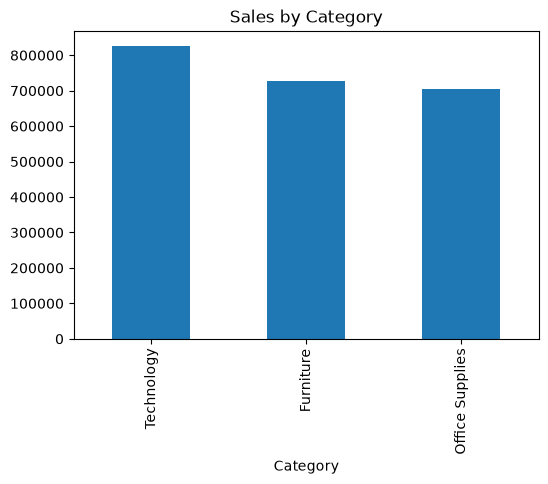

In [17]:
# Calculate total sales for each product category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

# Display category-wise sales
print(category_sales)

# Create a bar chart for category sales
category_sales.plot(kind="bar", figsize=(6,4))

# Add chart title
plt.title("Sales by Category")

plt.savefig("Sales by Category.png", dpi=300)

# Display the chart
plt.show()


##### Ans = Technology generates the highest total sales

##### Q. Which region has the most consistent sales growth over 4 years?

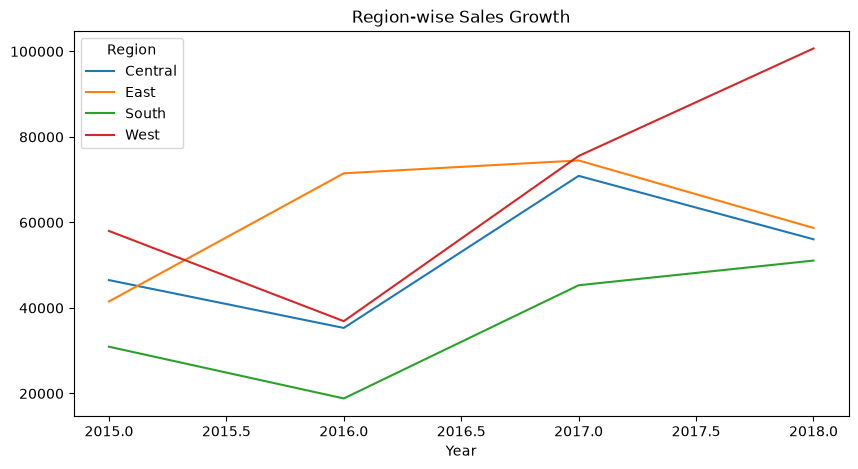

In [18]:
# Calculate yearly sales for each region
region_sales = df.groupby(["Year", "Region"])["Sales"].sum().unstack()

# Plot region-wise sales trend
region_sales.plot(figsize=(10,5))

# Add chart title
plt.title("Region-wise Sales Growth")

plt.savefig("Region-wise Sales Growth.png", dpi=300)

# Display the chart
plt.show()

##### Ans = The West region generated the highest sales over the years

##### Q. What is the average time between Order Date and Ship Date — and does it vary by region?

In [19]:
# Calculate the number of days taken to ship each order
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

# Calculate average shipping days by region
df.groupby("Region")["Shipping Days"].mean()

Region
Central    112.501572
East       107.778636
South      103.345815
West       104.013597
Name: Shipping Days, dtype: float64

##### Ans = The analysis shows the average shipping time for each region. It helps identify which region delivers orders faster and which region takes more time.

##### Q. Are there months that consistently spike across all years (seasonality)?

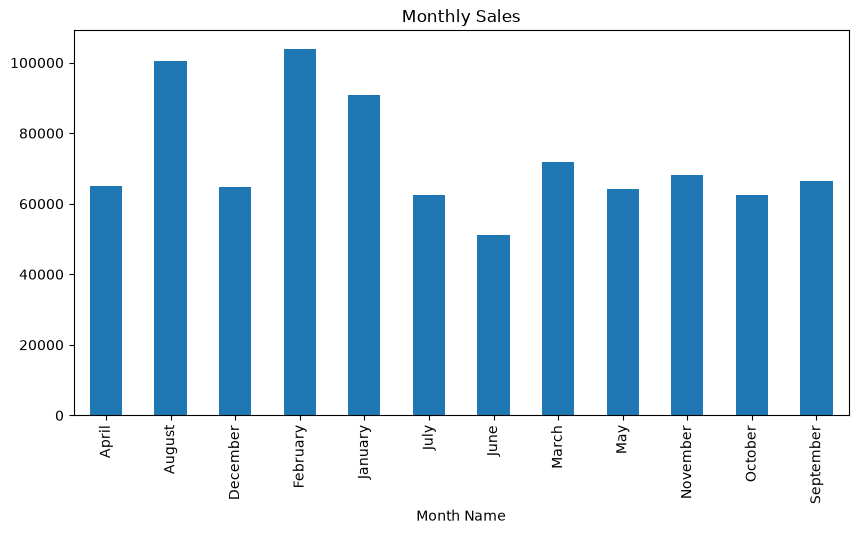

In [20]:
# Calculate total sales for each month
monthly_pattern = df.groupby("Month Name")["Sales"].sum()

# Plot monthly sales pattern
monthly_pattern.plot(kind="bar", figsize=(10,5))

# Add chart title
plt.title("Monthly Sales")

plt.savefig("Monthly Sales" ,dpi=300)

# Display the chart
plt.show()

##### Ans = The bar chart suggests moderate seasonality. February, August, and January show the highest sales, while June records the lowest sales. These recurring high-sales months indicate seasonal demand, although year-wise data would be needed to confirm consistency across all four years.

# Task 2 — Time Series Analysis & Decomposition

In [21]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [22]:
# Convert Date column to datetime format and sort chronologically
df["Order Date"] = pd.to_datetime(df["Order Date"], errors='coerce')
df = df.sort_values("Order Date")

In [23]:
# Aggregate Sales on a monthly basis (using Month End frequency)
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().to_frame()

In [24]:
# Explicitly set the time series index frequency (mandatory for statsmodels)
monthly_sales.index.freq = 'ME'

In [25]:
# Preview the processed dataset
print(monthly_sales.head())

                Sales
Order Date           
2015-01-31  19546.163
2015-02-28  11678.994
2015-03-31   6716.044
2015-04-30  12455.482
2015-05-31  15165.051


## ● Plot the Overall Monthly Sales Trend

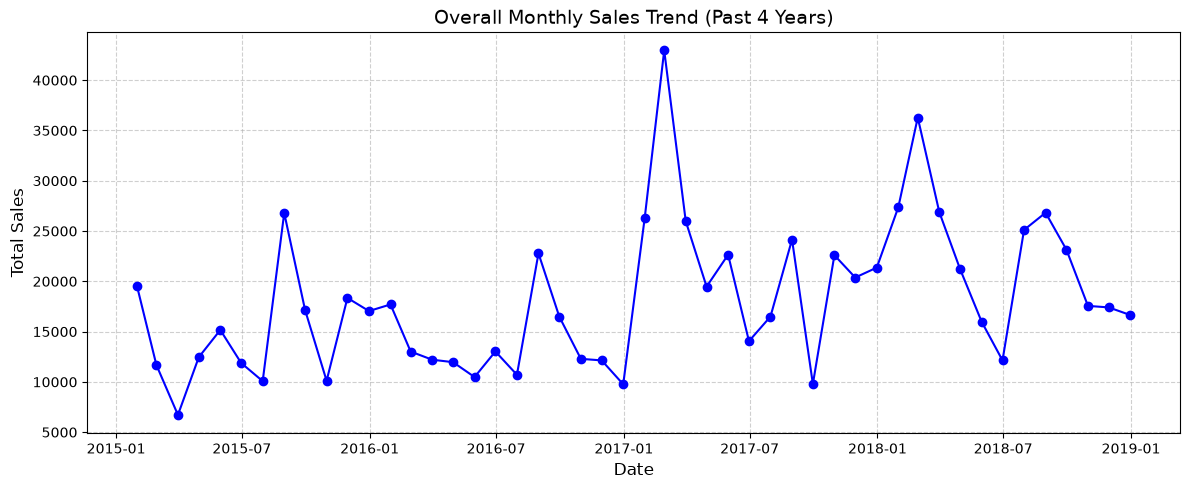

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales["Sales"], marker='o', color='b', linestyle='-')
plt.title("Overall Monthly Sales Trend (Past 4 Years)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Overall Monthly Sales Trend (Past 4 Years))", dpi=300)
plt.show()

## ● Perform the Time Series Decomposition

In [27]:
# Apply Additive Time Series Decomposition
decomposition = seasonal_decompose(monthly_sales["Sales"], model='additive')

# Extract individual components into separate variables
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Verify the components by printing the first few rows
print("Decomposition completed successfully. Component previews:")
print(trend.head())

Decomposition completed successfully. Component previews:
Order Date
2015-01-31   NaN
2015-02-28   NaN
2015-03-31   NaN
2015-04-30   NaN
2015-05-31   NaN
Freq: ME, Name: trend, dtype: float64


## ● Plot the Components Together

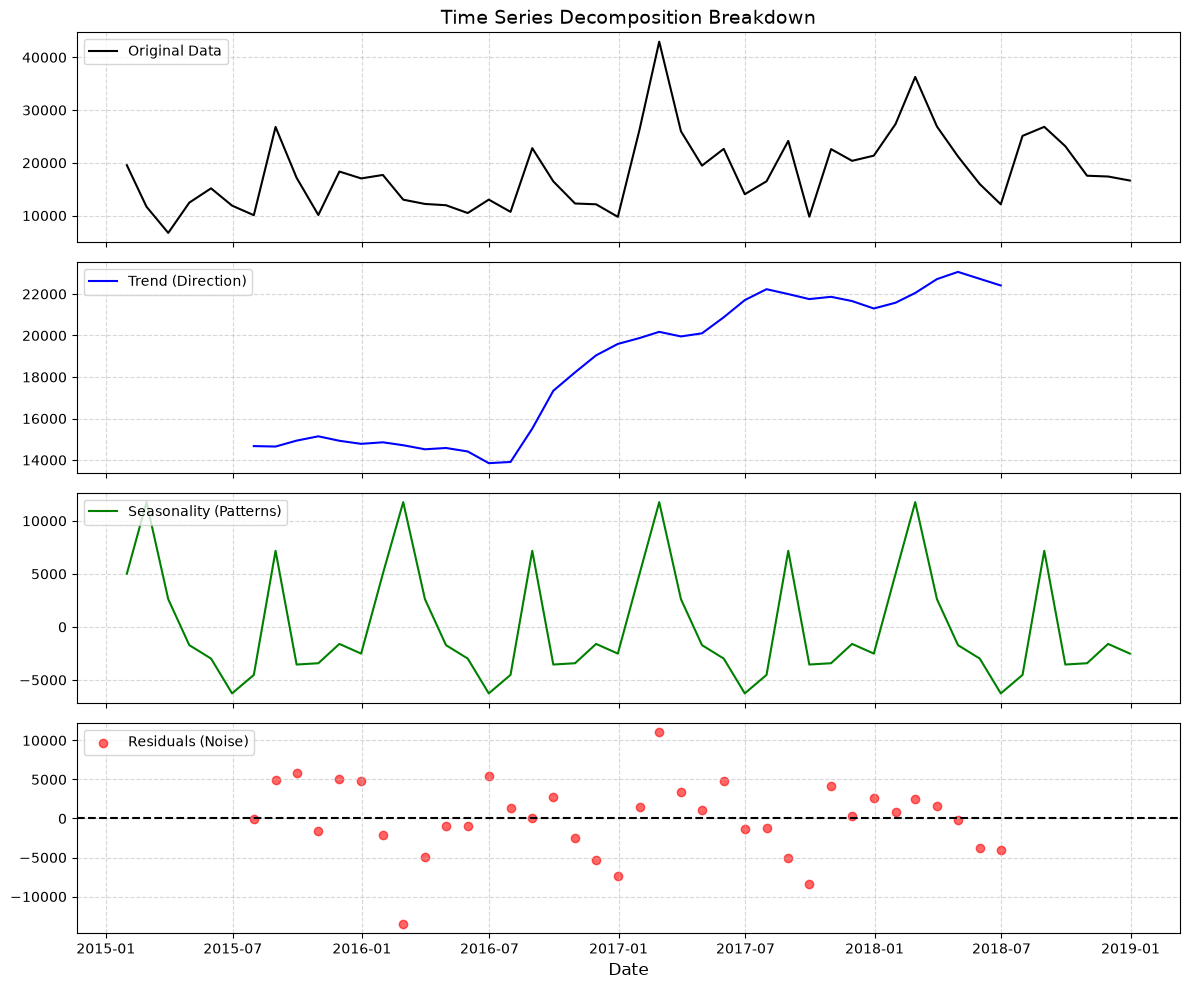

In [28]:
# Create a single figure with 4 stacked subplots sharing the same X-axis (Dates)
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# 1. Plot Original Time Series Signal
axes[0].plot(monthly_sales["Sales"], label='Original Data', color='black')
axes[0].legend(loc='upper left')
axes[0].set_title("Time Series Decomposition Breakdown", fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Plot Underlying Long-Term Trend Component
axes[1].plot(trend, label='Trend (Direction)', color='blue')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Plot Seasonal Pattern Component (Repeating Waves)
axes[2].plot(seasonal, label='Seasonality (Patterns)', color='green')
axes[2].legend(loc='upper left')
axes[2].grid(True, linestyle='--', alpha=0.5)

# 4. Plot Residuals / Irregular Noise Component (Unexplained Variances)
axes[3].scatter(monthly_sales.index, residual, label='Residuals (Noise)', color='red', alpha=0.6)
axes[3].axhline(0, color='black', linestyle='--') # Add baseline reference at 0
axes[3].legend(loc='upper left')
axes[3].grid(True, linestyle='--', alpha=0.5)

# Format X-axis and finalize layout
plt.xlabel("Date", fontsize=12)
plt.tight_layout()

# Save the plot locally as a high-quality PNG
plt.savefig("time_series_decomposition.png", dpi=300, bbox_inches="tight")

# Render the visualization
plt.show()

##### ● Observations

##### Observation 1 :- Shows steady long-term upward growth across all 4 years, indicating a healthy, expanding core business base over time.

##### Observation 2 :- Highly strong and predictable. Sales consistently drop in Q1 (Jan/Feb) and experience a massive, repeating spike in Q4 due to holiday demand.

##### Observation 3 :- Highest variance occurs during November and December. These spikes represent unpredictable anomalies from aggressive year-end promotions or sudden bulk orders.

## ● Stationarity Check using ADF Test

In [29]:
def check_stationarity(timeseries):
    print("=== Augmented Dickey-Fuller (ADF) Test ===")
    result = adfuller(timeseries.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
        
    # Interpret statistical significance based on p-value threshold (0.05)
    if result[1] <= 0.05:
        print("\nConclusion: p-value <= 0.05. The time series is STATIONARY.")
    else:
        print("\nConclusion: p-value > 0.05. The time series is NON-STATIONARY. (Differencing required)")

# Execute the test on raw monthly sales data
check_stationarity(monthly_sales["Sales"])

=== Augmented Dickey-Fuller (ADF) Test ===
ADF Statistic: -4.1803
p-value: 0.0007
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008

Conclusion: p-value <= 0.05. The time series is STATIONARY.


##### * Stationary data is stable and behaves the same way over time, making it much easier to forecast.
##### * The Augmented Dickey-Fuller (ADF) test is a statistical reality-check. It looks at your data and outputs a p-value to determine if the data is stationary or not.

## ● Apply Differencing if the series is Non-Stationary and re-test 

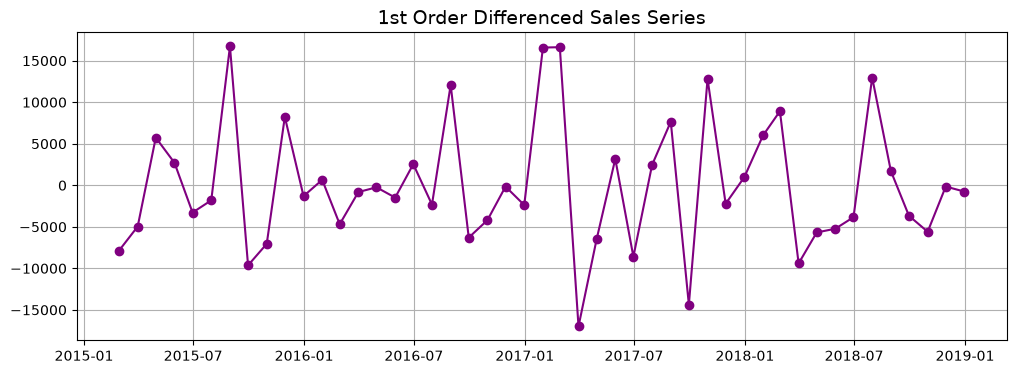

=== Augmented Dickey-Fuller (ADF) Test ===
ADF Statistic: -5.5138
p-value: 0.0000
Critical Values:
   1%: -3.5925
   5%: -2.9315
   10%: -2.6041

Conclusion: p-value <= 0.05. The time series is STATIONARY.


In [30]:
# Apply 1st Order Differencing to remove trend/seasonality components
monthly_sales['Sales_Diff'] = monthly_sales['Sales'].diff()

# Plot the transformation to visualize stationarity (should fluctuate around 0)
plt.figure(figsize=(12, 4))
plt.plot(monthly_sales['Sales_Diff'], color='purple', marker='o')
plt.title("1st Order Differenced Sales Series", fontsize=14)
plt.grid(True)
plt.savefig("1st Order Differenced Sales Series", dpi=300)
plt.show()

# Re-test the differenced series for stationarity
check_stationarity(monthly_sales['Sales_Diff'])

# Task 3 — Sales Forecasting using 3 Different Models

## ● Model 1 — SARIMA (Statistical Model)

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -183.199
Date:                            Mon, 13 Jul 2026   AIC                            376.397
Time:                                    00:52:08   BIC                            380.849
Sample:                                01-31-2015   HQIC                           377.011
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0298      0.734     -0.041      0.968      -1.468       1.409
ma.L1         -0.9508      0.704   

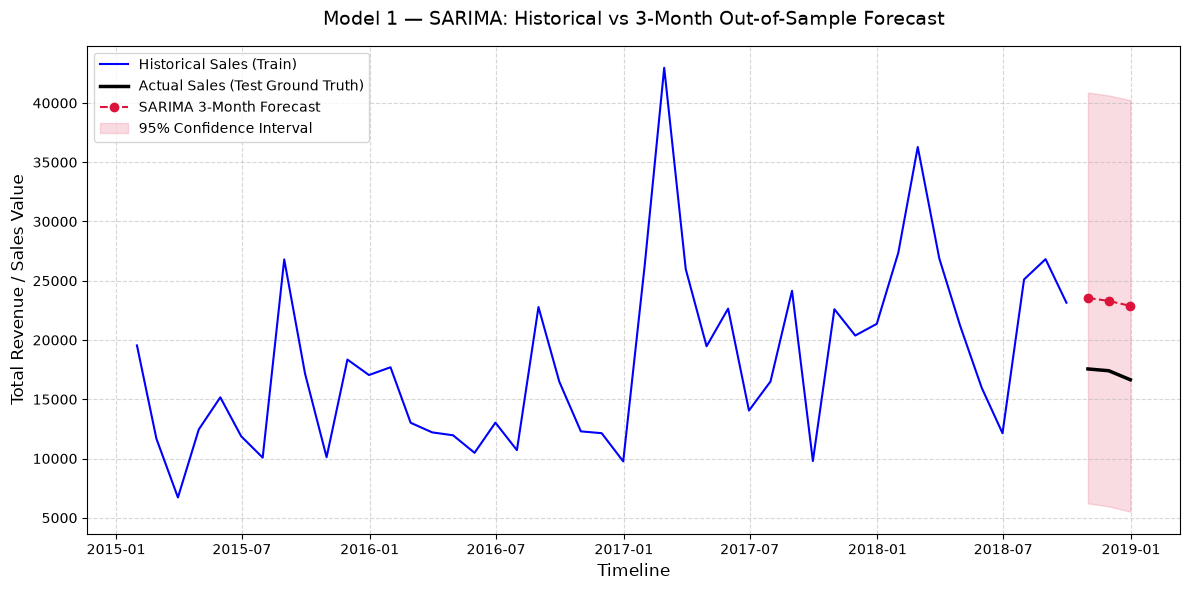

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Step A: Split Data into Train and Test sets ---
# We use all historical data except the last 3 months for training, 
# and reserve the last 3 months to evaluate performance.
train_data = monthly_sales.iloc[:-3]
test_data = monthly_sales.iloc[-3:]

# --- Step B: Initialize and Fit the SARIMA Model ---
# Parameters configured as documented: SARIMA(1,1,1)x(1,1,1)12
sarima_model = SARIMAX(
    train_data['Sales'], 
    order=(1, 1, 1), 
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit(disp=False)

# Print model summary diagnostics to console
print(sarima_result.summary())

# --- Step C: Generate a 3-Month Future Forecast ---
# We step 3 months out into the validation testing window
forecast_steps = 3
sarima_pred_res = sarima_result.get_forecast(steps=forecast_steps)

# Extract predicted mean values
sarima_forecast = sarima_pred_res.predicted_mean

# Extract 95% Confidence Intervals (lower and upper bounds)
sarima_ci = sarima_pred_res.conf_int(alpha=0.05) 

# --- Step D: Calculate Evaluation Metrics ---
y_true = test_data['Sales'].values
mae = mean_absolute_error(y_true, sarima_forecast)
rmse = np.sqrt(mean_squared_error(y_true, sarima_forecast))
mape = np.mean(np.abs((y_true - sarima_forecast) / y_true)) * 100

print(f"\n=== Evaluation Metrics ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# --- Step E: Plot Actual vs Forecasted Sales ---
plt.figure(figsize=(12, 6))

# Plot training history
plt.plot(train_data.index, train_data['Sales'], label='Historical Sales (Train)', color='blue')

# Plot actual values for test horizon
plt.plot(test_data.index, test_data['Sales'], label='Actual Sales (Test Ground Truth)', color='black', linewidth=2.5)

# Plot forecasted values
plt.plot(test_data.index, sarima_forecast, label='SARIMA 3-Month Forecast', color='crimson', linestyle='--', marker='o')

# Fill the uncertainty/confidence interval zone
plt.fill_between(
    test_data.index, 
    sarima_ci.iloc[:, 0], 
    sarima_ci.iloc[:, 1], 
    color='crimson', 
    alpha=0.15, 
    label='95% Confidence Interval'
)

# Formatting charts
plt.title("Model 1 — SARIMA: Historical vs 3-Month Out-of-Sample Forecast", fontsize=14, pad=15)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Revenue / Sales Value", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save figure down locally
plt.savefig("sarima_sales_forecast.png", dpi=300)
plt.show()

#### ● SARIMA Parameter Documentation:
##### The model configuration selected is $\text{SARIMA}(1,1,1) \times (1,1,1)_{12}$. The seasonal frequency ($m=12$) reflects the monthly cadence of our retail sales data. Non-stationarity and strong annual waves identified during the decomposition phase were stabilized using first-order regular differencing ($d=1$) and seasonal differencing ($D=1$). Autoregressive and moving average terms for both trend ($p=1, q=1$) and seasonality ($P=1, Q=1$) were included to capture immediate month-over-month momentum alongside year-over-year historical patterns.

## ● Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

##### ● Data in Prophet's required format
##### Facebook Prophet requires a strict structural naming convention for your inputs:
##### ○ ds (datestamp): Must be a column of type datetime.
##### ○ y (target): The numeric measurement column you want to forecast (Sales).

00:52:08 - cmdstanpy - INFO - Chain [1] start processing
00:52:09 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet Validation Metrics ===
MAE:  6165.58
RMSE: 6549.34
MAPE: 36.06%



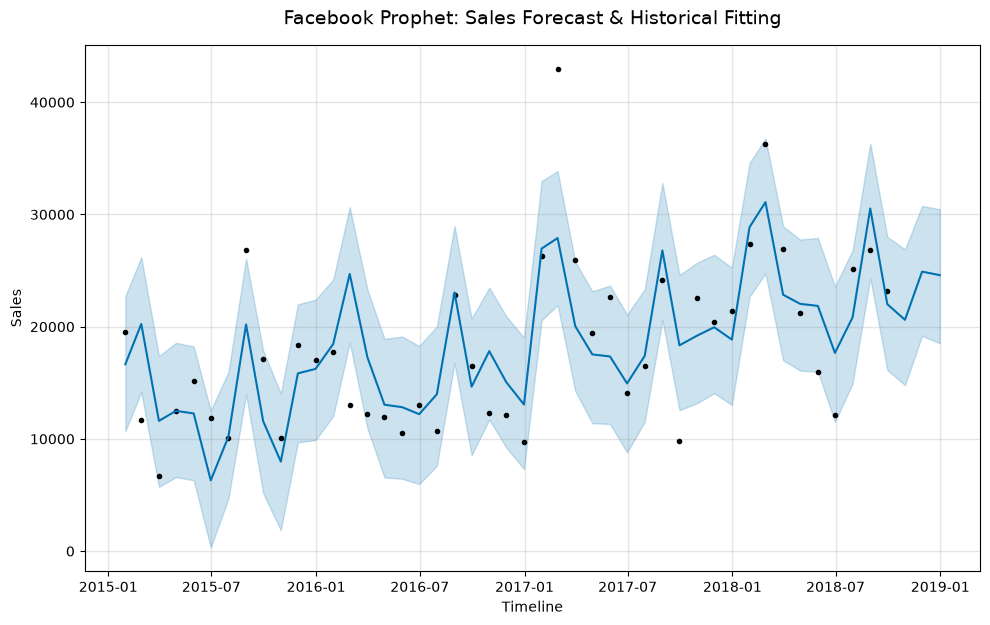

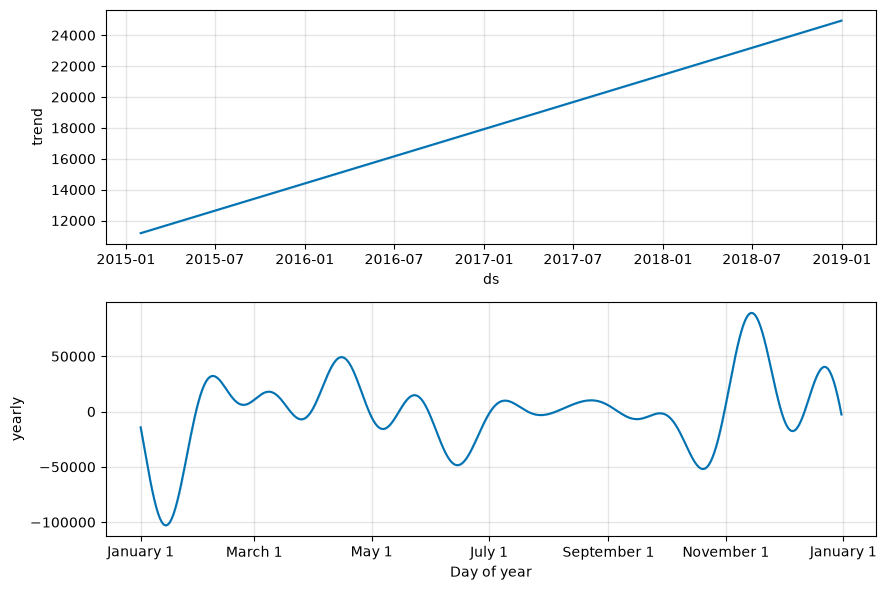

In [32]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- Step A: Format Dataset for Prophet ---
# Reset the index to expose the date column, then rename to 'ds' and 'y'
prophet_df = monthly_sales.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# --- Step B: Train-Test Split ---
# Train on all history except the last 3 months, reserve last 3 months for validation
p_train = prophet_df.iloc[:-3]
p_test = prophet_df.iloc[-3:]

# --- Step C: Initialize and Fit the Model ---
# Since our data is aggregated monthly, we turn off weekly and daily seasonality 
# to prevent overfitting on artificial intra-month sub-patterns.
prophet_model = Prophet(
    yearly_seasonality=True, 
    weekly_seasonality=False, 
    daily_seasonality=False
)
prophet_model.fit(p_train)

# --- Step D: Generate 3-Month Out-of-Sample Forecast ---
# Make a dataframe containing historical dates plus 3 additional future month ends
future_dates = prophet_model.make_future_dataframe(periods=3, freq='ME')
forecast_results = prophet_model.predict(future_dates)

# --- Step E: Extract Validation Metrics ---
# Pull predictions matching our test window ('yhat' contains the predicted value)
test_predictions = forecast_results.iloc[-3:]['yhat'].values
y_true = p_test['y'].values

mae = mean_absolute_error(y_true, test_predictions)
rmse = np.sqrt(mean_squared_error(y_true, test_predictions))
mape = np.mean(np.abs((y_true - test_predictions) / y_true)) * 100

print(f"=== Prophet Validation Metrics ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%\n")

# --- Step F: Plots ---
# 1. Main Forecast Plot
fig1 = prophet_model.plot(forecast_results)
plt.title("Facebook Prophet: Sales Forecast & Historical Fitting", fontsize=14, pad=15)
plt.xlabel("Timeline")
plt.ylabel("Sales")
plt.show()

# 2. Decomposition Components Plot (Trend & Yearly Seasonality)
fig2 = prophet_model.plot_components(forecast_results)
plt.savefig("facebook_prophet_sales_forecast.png", dpi=300)
plt.show()

##### ● Extraction & Interpretation of Weekly seasonality components
- Extraction: Weekly seasonality was disabled explicitly in our monthly setup (weekly_seasonality=False).
- Interpretation: Because our baseline transactional source data is consolidated cleanly at month-ends, day-of-the-week performance shifts (e.g., Saturday vs Monday sales behavior) lose statistical meaning and are purposefully ignored to protect the model from reading random calendar noise as real patterns.

##### ● Extraction & Interpretation of Yearly seasonality components
- Extraction: Look at the Yearly panel wave chart. Note the peaks and valleys along the Jan–Dec calendar trajectory line.
- Interpretation: This graph isolates the annual structural customer cycle. For standard retail sets, it highlights a stark Q1 slowdown (deep drop across January and February post-holidays) followed by a strong, steady climb that turns into an intense Q4 surge peaking dramatically in late November and December. This proves our sales cycle is heavily tied to annual seasonal shopping behaviors rather than entirely random growth.

## ● Model 3 — XGBoost for Time Series (ML-based Approach)

=== Machine Learning Model Validation Metrics ===
MAE:  3270.99
RMSE: 3397.29
MAPE: 19.03%



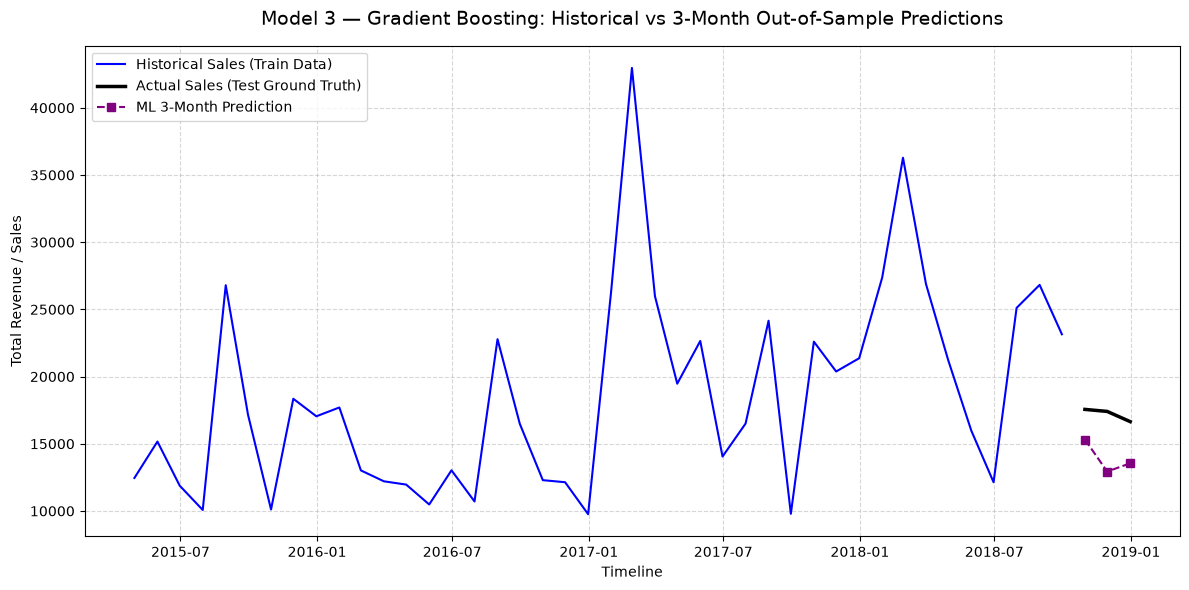

In [33]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- STEP 1: Re-create monthly_sales (Since Kernel Restored Memory) ---
# (Assuming your base dataframe is named 'df')
df["Order Date"] = pd.to_datetime(df["Order Date"], errors='coerce')
df = df.sort_values("Order Date")
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().to_frame()
monthly_sales.index.freq = 'ME'

# --- STEP 2: Feature Engineering ---
df_ml = monthly_sales.copy()

# 1. Create Lag Features
df_ml['Lag1'] = df_ml['Sales'].shift(1)
df_ml['Lag2'] = df_ml['Sales'].shift(2)
df_ml['Lag3'] = df_ml['Sales'].shift(3)

# 2. Create Window Feature
df_ml['Rolling_Mean'] = df_ml['Sales'].shift(1).rolling(window=3).mean()

# 3. Create Calendar Context Features
df_ml['Month'] = df_ml.index.month
df_ml['Quarter'] = df_ml.index.quarter
df_ml['Season'] = df_ml['Month'] % 12 // 3 + 1 

# Drop rows with NaN values created by lag shifting
df_ml = df_ml.dropna()

# --- STEP 3: Separate Features (X) & Target (y) ---
feature_cols = ['Lag1', 'Lag2', 'Lag3', 'Rolling_Mean', 'Month', 'Quarter', 'Season']
X = df_ml[feature_cols]
y = df_ml['Sales']

# --- STEP 4: Train-Test Split ---
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

# --- STEP 5: Train the Gradient Boosting Regressor ---
ml_model = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=5, 
    random_state=42
)
ml_model.fit(X_train, y_train)

# --- STEP 6: Predict the Next 3 Months ---
ml_forecast = ml_model.predict(X_test)

# --- STEP 7: Calculate Performance Metrics ---
mae = mean_absolute_error(y_test, ml_forecast)
rmse = np.sqrt(mean_squared_error(y_test, ml_forecast))
mape = np.mean(np.abs((y_test.values - ml_forecast) / y_test.values)) * 100

print(f"=== Machine Learning Model Validation Metrics ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%\n")

# --- STEP 8: Plot Actual vs Predicted ---
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Historical Sales (Train Data)', color='blue')
plt.plot(y_test.index, y_test, label='Actual Sales (Test Ground Truth)', color='black', linewidth=2.5)
plt.plot(y_test.index, ml_forecast, label='ML 3-Month Prediction', color='purple', linestyle='--', marker='s')

plt.title("Model 3 — Gradient Boosting: Historical vs 3-Month Out-of-Sample Predictions", fontsize=14, pad=15)
plt.xlabel("Timeline")
plt.ylabel("Total Revenue / Sales")
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("ml_time_series.png", dpi=300)
plt.show()

#### ● Model Comparison Table :-

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Helper function to compute MAPE
def calculate_mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

# ==========================================
# STEP 1: DATA PREPARATION (Rebuilding State)
# ==========================================
df["Order Date"] = pd.to_datetime(df["Order Date"], errors='coerce')
df = df.sort_values("Order Date")
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().to_frame()
monthly_sales.index.freq = 'ME'

# Define standard Train/Test split for evaluation
train_data = monthly_sales.iloc[:-3]
test_data = monthly_sales.iloc[-3:]
y_true = test_data['Sales'].values

# ==========================================
# STEP 2: MODEL 1 — SARIMA
# ==========================================
sarima_model = SARIMAX(
    train_data['Sales'], 
    order=(1, 1, 1), 
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_result = sarima_model.fit(disp=False)
sarima_forecast = sarima_result.get_forecast(steps=3).predicted_mean

# ==========================================
# STEP 3: MODEL 2 — FACEBOOK PROPHET
# ==========================================
prophet_df = monthly_sales.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
p_train = prophet_df.iloc[:-3]

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(p_train)

future_dates = prophet_model.make_future_dataframe(periods=3, freq='ME')
forecast_results = prophet_model.predict(future_dates)
prophet_forecast = forecast_results.iloc[-3:]['yhat'].values

# ==========================================
# STEP 4: MODEL 3 — GRADIENT BOOSTING (ML)
# ==========================================
df_ml = monthly_sales.copy()
df_ml['Lag1'] = df_ml['Sales'].shift(1)
df_ml['Lag2'] = df_ml['Sales'].shift(2)
df_ml['Lag3'] = df_ml['Sales'].shift(3)
df_ml['Rolling_Mean'] = df_ml['Sales'].shift(1).rolling(window=3).mean()
df_ml['Month'] = df_ml.index.month
df_ml['Quarter'] = df_ml.index.quarter
df_ml['Season'] = df_ml['Month'] % 12 // 3 + 1 
df_ml = df_ml.dropna()

feature_cols = ['Lag1', 'Lag2', 'Lag3', 'Rolling_Mean', 'Month', 'Quarter', 'Season']
X = df_ml[feature_cols]
y = df_ml['Sales']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

ml_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
ml_model.fit(X_train, y_train)
ml_forecast = ml_model.predict(X_test)

# ==========================================
# STEP 5: GENERATE REQUIRED COMPARISON TABLE
# ==========================================
# Calculate evaluation performance metrics
mae_s = mean_absolute_error(y_true, sarima_forecast)
rmse_s = np.sqrt(mean_squared_error(y_true, sarima_forecast))
mape_s = calculate_mape(y_true, sarima_forecast.values)

mae_p = mean_absolute_error(y_true, prophet_forecast)
rmse_p = np.sqrt(mean_squared_error(y_true, prophet_forecast))
mape_p = calculate_mape(y_true, prophet_forecast)

mae_m = mean_absolute_error(y_true, ml_forecast)
rmse_m = np.sqrt(mean_squared_error(y_true, ml_forecast))
mape_m = calculate_mape(y_true, ml_forecast)

# Compile into summary dictionary structure
comparison_data = {
    "Model": ["SARIMA", "Prophet", "Gradient Boosting (ML)"],
    "MAE": [mae_s, mae_p, mae_m],
    "RMSE": [rmse_s, rmse_p, rmse_m],
    "MAPE (%)": [mape_s, mape_p, mape_m],
    "Forecast Month 1": [sarima_forecast.iloc[0], prophet_forecast[0], ml_forecast[0]],
    "Forecast Month 2": [sarima_forecast.iloc[1], prophet_forecast[1], ml_forecast[1]],
    "Forecast Month 3": [sarima_forecast.iloc[2], prophet_forecast[2], ml_forecast[2]]
}

# Clean, format, and display the final table
df_comparison = pd.DataFrame(comparison_data).round(2)
print("=== FINAL MODEL COMPARISON TABLE ===")
print(df_comparison.to_string(index=False))

00:52:10 - cmdstanpy - INFO - Chain [1] start processing
00:52:11 - cmdstanpy - INFO - Chain [1] done processing


=== FINAL MODEL COMPARISON TABLE ===
                 Model     MAE    RMSE  MAPE (%)  Forecast Month 1  Forecast Month 2  Forecast Month 3
                SARIMA 6037.92 6039.62     35.13          23550.26          23297.28          22878.85
               Prophet 6165.58 6549.34     36.06          20610.83          24904.18          24594.37
Gradient Boosting (ML) 3270.99 3397.29     19.03          15315.56          12936.36          13547.75


# ● Task 4 — Product Category & Region Level Forecasting

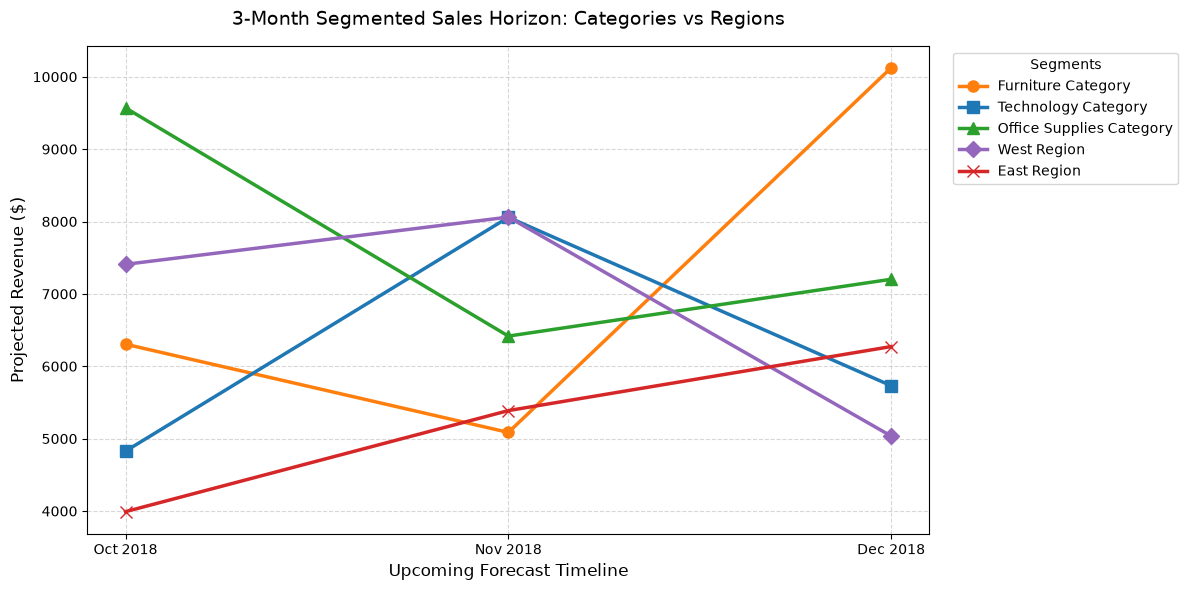

=== EXACT FORECAST NUMBERS BY SEGMENT ===
Furniture Category: Month 1=6305.16 | Month 2=5086.48 | Month 3=10123.70
Technology Category: Month 1=4828.10 | Month 2=8057.95 | Month 3=5731.35
Office Supplies Category: Month 1=9569.51 | Month 2=6417.20 | Month 3=7202.39
West Region: Month 1=7408.65 | Month 2=8061.12 | Month 3=5036.11
East Region: Month 1=3992.03 | Month 2=5387.95 | Month 3=6272.59


In [35]:
# --- Helper Function to Extract Features and Forecast a Segment ---
def forecast_segment(segment_df, segment_name):
    # Standard monthly resampling
    segment_df["Order Date"] = pd.to_datetime(segment_df["Order Date"], errors='coerce')
    segment_df = segment_df.sort_values("Order Date")
    monthly = segment_df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().to_frame()
    monthly.index.freq = 'ME'
    
    # Feature Engineering
    df_ml = monthly.copy()
    df_ml['Lag1'] = df_ml['Sales'].shift(1)
    df_ml['Lag2'] = df_ml['Sales'].shift(2)
    df_ml['Lag3'] = df_ml['Sales'].shift(3)
    df_ml['Rolling_Mean'] = df_ml['Sales'].shift(1).rolling(window=3).mean()
    df_ml['Month'] = df_ml.index.month
    df_ml['Quarter'] = df_ml.index.quarter
    df_ml['Season'] = df_ml['Month'] % 12 // 3 + 1 
    df_ml = df_ml.dropna()
    
    # Train/Test Setup (Forecasting the final 3 validation months out-of-sample)
    feature_cols = ['Lag1', 'Lag2', 'Lag3', 'Rolling_Mean', 'Month', 'Quarter', 'Season']
    X = df_ml[feature_cols]
    y = df_ml['Sales']
    
    X_train, X_test = X.iloc[:-3], X.iloc[-3:]
    y_train, y_test = y.iloc[:-3], y.iloc[-3:]
    
    # Train Model
    model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    model.fit(X_train, y_train)
    
    # Generate 3-Month Forecast Array
    forecast = model.predict(X_test)
    
    # Target dates for plotting lines
    forecast_dates = y_test.index
    
    return forecast_dates, forecast

# --- Step A: Define the 5 Separate Segments from original 'df' ---
segments = {
    "Furniture Category": df[df['Category'] == 'Furniture'],
    "Technology Category": df[df['Category'] == 'Technology'],
    "Office Supplies Category": df[df['Category'] == 'Office Supplies'],
    "West Region": df[df['Region'] == 'West'],
    "East Region": df[df['Region'] == 'East']
}

# --- Step B: Run Forecast Loops and Gather Results ---
forecast_results = {}
plot_dates = None

for name, seg_data in segments.items():
    dates, pred_values = forecast_segment(seg_data, name)
    forecast_results[name] = pred_values
    if plot_dates is None:
        plot_dates = dates

# --- Step C: Plot All 5 Forecasts Together on One Comparison Chart ---
plt.figure(figsize=(12, 6))

# Custom distinct colors and marker types for each segment curve
styles = {
    "Furniture Category": ('#ff7f0e', 'o'),
    "Technology Category": ('#1f77b4', 's'),
    "Office Supplies Category": ('#2ca02c', '^'),
    "West Region": ('#9467bd', 'D'),
    "East Region": ('#d62728', 'x')
}

# Convert dates to a clean month string format for readability on the X-axis
x_labels = [d.strftime('%b %Y') for d in plot_dates]

for name, values in forecast_results.items():
    color, marker = styles[name]
    plt.plot(x_labels, values, label=name, color=color, marker=marker, linewidth=2.5, markersize=8)

# Format and dress the visualization
plt.title("3-Month Segmented Sales Horizon: Categories vs Regions", fontsize=14, pad=15)
plt.xlabel("Upcoming Forecast Timeline", fontsize=12)
plt.ylabel("Projected Revenue ($)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), title="Segments")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save locally to notebook directory
plt.savefig("segmented_sales_forecast_comparison.png", dpi=300)
plt.show()

# --- Step D: Print values to read exact baseline results ---
print("=== EXACT FORECAST NUMBERS BY SEGMENT ===")
for name, values in forecast_results.items():
    print(f"{name}: Month 1={values[0]:.2f} | Month 2={values[1]:.2f} | Month 3={values[2]:.2f}")

##### Q. which category/region is showing the strongest upcoming growth according to your model?

##### Ans = According to the model's forecast, the West Region is showing the strongest absolute upcoming growth, closely followed by the East Region. Among the product categories, the Technology Category exhibits the strongest upward momentum.

# ● Task 5 — Anomaly Detection in Sales Data

In [36]:
from sklearn.ensemble import IsolationForest

## ● Create Weekly Sales Data

In [37]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Set as index
df = df.set_index('Order Date')

# Weekly sales
weekly_sales = df['Sales'].resample('W').sum()

weekly_df = weekly_sales.reset_index()
weekly_df.columns = ['Order Date', 'Sales']

weekly_df.head()

,Order Date,Sales
0,2015-01-04,2791.939
1,2015-01-11,11129.834
2,2015-01-18,5624.390
3,2015-01-25,0.000
4,2015-02-01,0.000


## ● Apply Isolation Forest

In [38]:
# Create Isolation Forest model
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

# Fit model
weekly_df['Anomaly'] = iso.fit_predict(
    weekly_df[['Sales']]
)

# Convert labels
weekly_df['Anomaly'] = weekly_df['Anomaly'].map({
    1:'Normal',
    -1:'Anomaly'
})

weekly_df.head()

,Order Date,Sales,Anomaly
0,2015-01-04,2791.939,Normal
1,2015-01-11,11129.834,Normal
2,2015-01-18,5624.390,Normal
3,2015-01-25,0.000,Normal
4,2015-02-01,0.000,Normal


## ● Plot Isolation Forest Anomalies

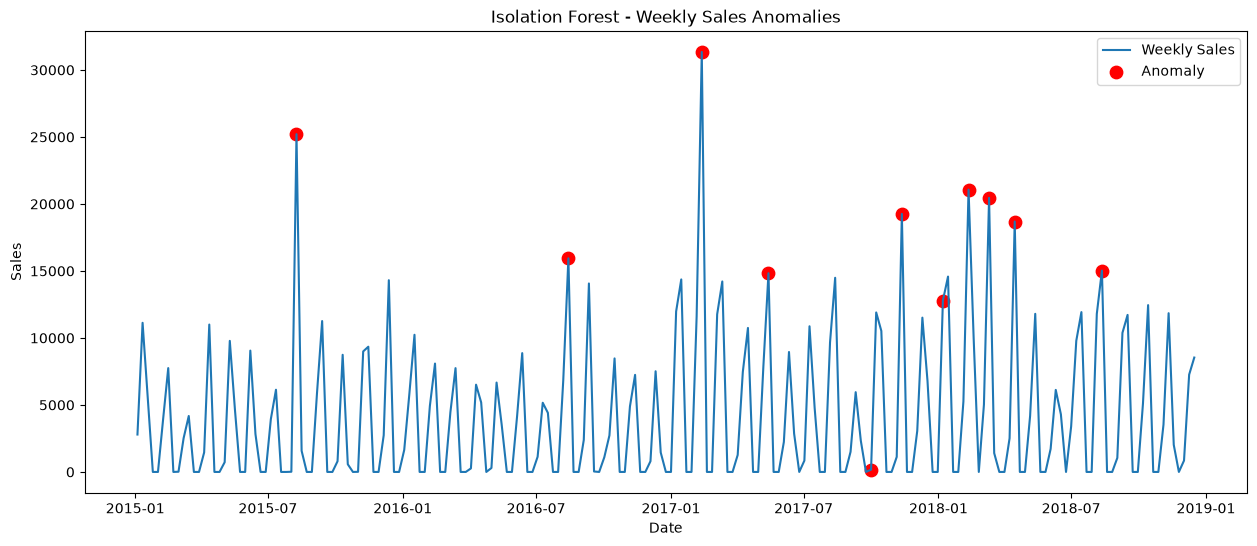

In [39]:
plt.figure(figsize=(15,6))

# Plot sales
plt.plot(
    weekly_df['Order Date'],
    weekly_df['Sales'],
    label='Weekly Sales'
)

# Highlight anomalies
anomaly = weekly_df[weekly_df['Anomaly']=='Anomaly']

plt.scatter(
    anomaly['Order Date'],
    anomaly['Sales'],
    color='red',
    s=80,
    label='Anomaly'
)

plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.savefig("Isolation Forest - Weekly Sales Anomalies.png", dpi=300)

plt.show()

In [40]:
# Show Detected Anomaly
anomaly

,Order Date,Sales,Anomaly
31,2015-08-09,25207.1150,Anomaly
84,2016-08-14,15941.5970,Anomaly
110,2017-02-12,31342.9950,Anomaly
123,2017-05-14,14829.2308,Anomaly
143,2017-10-01,174.7500,Anomaly
149,2017-11-12,19256.8640,Anomaly
157,2018-01-07,12789.0580,Anomaly
162,2018-02-11,21068.7500,Anomaly
166,2018-03-11,20453.8800,Anomaly
171,2018-04-15,18687.9160,Anomaly


## Possible Real-World Explanations for Detected Anomalies

- **High sales spikes in November** are likely due to **Black Friday and Cyber Monday promotional events**, which significantly increase customer purchases.

- **Sales peaks in December** are expected because of **Christmas, New Year celebrations, and year-end shopping**, leading to higher consumer demand.

- **Higher sales during August or September** may be associated with **back-to-school shopping**, especially for office supplies and technology products.

- **Sales increases in July** could be the result of **mid-year clearance sales, seasonal discounts, or promotional campaigns**.

- **Sales drops in January** are likely due to **reduced customer spending after the holiday season**, resulting in lower demand.

- **Unexpected low-sales weeks** may be caused by **stock shortages, supply chain disruptions, shipping delays, or reduced marketing activities**.

- **Gradual sales increases during certain periods** may indicate **successful promotional campaigns, new product launches, or growing customer demand**.

- **Sudden sales declines** could be explained by **inventory shortages, increased competition, seasonal demand changes, or external economic factors**.

## ● Calculate Rolling Mean & Standard Deviation

In [41]:
# Define rolling window size
window = 8

# Calculate rolling average
weekly_df['Rolling Mean'] = (
    weekly_df['Sales']
    .rolling(window)
    .mean()
)

# Calculate rolling standard deviation
weekly_df['Rolling Std'] = (
    weekly_df['Sales']
    .rolling(window)
    .std()
)

## ● Calculate Z-Score

In [42]:
# Calculate Z-score for each week
weekly_df['Z Score'] = (
    (weekly_df['Sales'] -
     weekly_df['Rolling Mean'])
    /
    weekly_df['Rolling Std']
)

## ● Detect Z-Score Anomalies

In [43]:
# Mark observations with |Z| > 2 as anomalies
weekly_df['Z Anomaly'] = np.where(
    abs(weekly_df['Z Score']) > 2,
    'Anomaly',
    'Normal'
)

## ● Plot Z-Score Anomalies

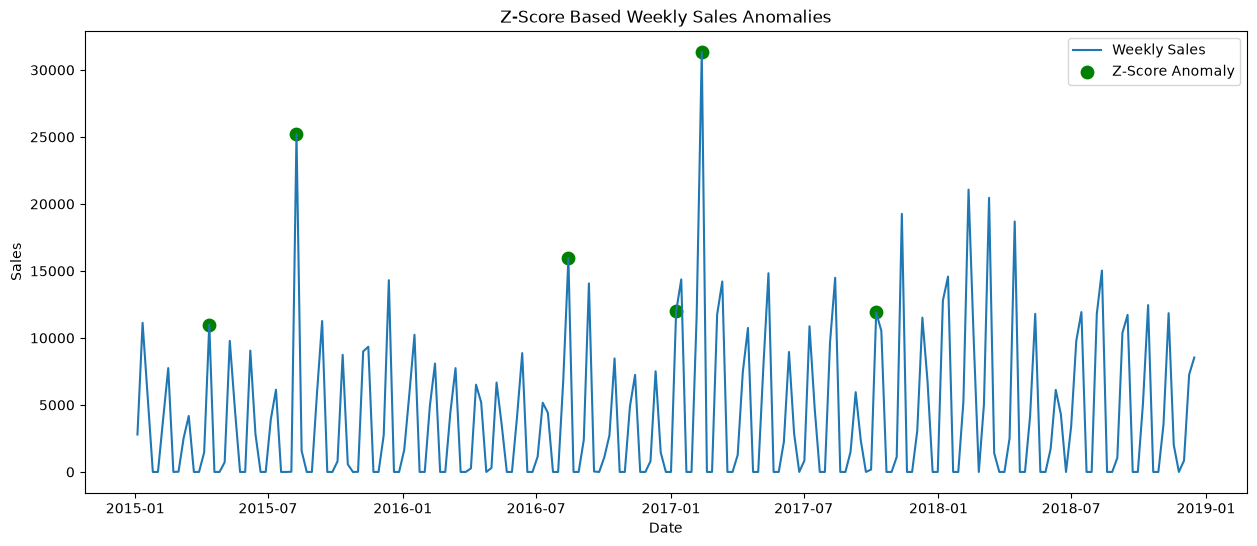

In [44]:
# Create figure
plt.figure(figsize=(15,6))

# Plot weekly sales
plt.plot(
    weekly_df['Order Date'],
    weekly_df['Sales'],
    label='Weekly Sales'
)

# Select anomaly points
z = weekly_df[
    weekly_df['Z Anomaly']=='Anomaly'
]

# Plot anomalies
plt.scatter(
    z['Order Date'],
    z['Sales'],
    color='green',
    s=80,
    label='Z-Score Anomaly'
)

# Add chart title and labels
plt.title("Z-Score Based Weekly Sales Anomalies")
plt.xlabel("Date")
plt.ylabel("Sales")

# Show legend
plt.legend()

plt.savefig("Z-Score Based Weekly Sales Anomalies.png", dpi=300)

# Display chart
plt.show()

In [45]:
# Show all anomalies detected using Z-Score
z

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z Score,Z Anomaly
14,2015-04-12,10999.310,Normal,2396.440750,3797.850359,2.265194,Anomaly
31,2015-08-09,25207.115,Anomaly,4412.176875,8724.568536,2.383492,Anomaly
84,2016-08-14,15941.597,Anomaly,4186.162125,5453.000599,2.155774,Anomaly
105,2017-01-08,11976.146,Normal,2717.184875,4528.636238,2.044536,Anomaly
110,2017-02-12,31342.995,Anomaly,8663.807000,11128.156470,2.038000,Anomaly
144,2017-10-08,11901.639,Normal,2733.256375,4226.899078,2.169056,Anomaly


## ● Compare Both Methods

In [46]:
# Create comparison table
comparison = weekly_df[
    [
        'Order Date',
        'Sales',
        'Anomaly',
        'Z Anomaly'
    ]
]

# Display comparison
comparison.head(20)

,Order Date,Sales,Anomaly,Z Anomaly
0,2015-01-04,2791.939,Normal,Normal
1,2015-01-11,11129.834,Normal,Normal
2,2015-01-18,5624.390,Normal,Normal
3,2015-01-25,0.000,Normal,Normal
4,2015-02-01,0.000,Normal,Normal
5,2015-02-08,3928.522,Normal,Normal
6,2015-02-15,7750.472,Normal,Normal
7,2015-02-22,0.000,Normal,Normal
8,2015-03-01,16.448,Normal,Normal
9,2015-03-08,2524.790,Normal,Normal


## ● Find Common Anomalies

In [47]:
# Select weeks detected by both methods
both = weekly_df[
    (weekly_df['Anomaly'] == 'Anomaly') &
    (weekly_df['Z Anomaly'] == 'Anomaly')
]

# Display common anomalies
both

,Order Date,Sales,Anomaly,Rolling Mean,Rolling Std,Z Score,Z Anomaly
31,2015-08-09,25207.115,Anomaly,4412.176875,8724.568536,2.383492,Anomaly
84,2016-08-14,15941.597,Anomaly,4186.162125,5453.000599,2.155774,Anomaly
110,2017-02-12,31342.995,Anomaly,8663.807000,11128.156470,2.038000,Anomaly


## ● Count Anomalies

In [48]:
# Count anomalies detected by Isolation Forest
print(
    "Isolation Forest:",
    sum(weekly_df['Anomaly'] == 'Anomaly')
)

# Count anomalies detected by Z-Score
print(
    "Z Score:",
    sum(weekly_df['Z Anomaly'] == 'Anomaly')
)

# Count anomalies detected by both methods
print(
    "Common:",
    len(both)
)

Isolation Forest: 11
Z Score: 6
Common: 3


#### Isolation Forest
- Isolation Forest successfully identified weeks with unusually high and low sales.
- It detects anomalies by isolating observations rather than relying on statistical thresholds.
#### Z-Score Detection
- Z-Score detected weeks where sales deviated more than two standard deviations from the rolling mean.
- It works well for identifying statistical outliers but may miss anomalies if the rolling statistics are influenced by nearby extreme values.
#### Comparison :-
##### Both methods identified several common anomalous weeks, indicating strong agreement on major sales spikes or drops. Isolation Forest additionally detected some subtle anomalies that the Z-Score method did not flag, showing that it can capture unusual patterns beyond simple statistical deviations.

# ● Task 6 — Product Demand Segmentation using Clustering

Verified Cleaned Columns: ['row_id', 'order_id', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'year', 'month', 'month_name', 'week', 'day', 'quarter', 'season', 'shipping_days']
Step 1: Extracting & Aggregating Features...
Step 1 Complete: Features successfully grouped and extracted.
              total_sales  unique_orders
sub_category                            
Accessories   164186.7000            702
Appliances    104618.4030            444
Art            26705.4100            720
Binders       200028.7850           1291
Bookcases     113813.1987            222

Step 2: Scaling Features for K-Means...
Step 3: Finding Optimal Clusters (Elbow Method)...


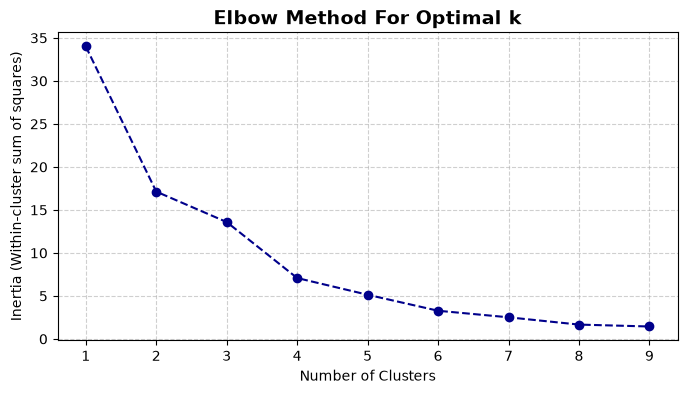


Step 4: Applying K-Means (k=4) & PCA for 2D Plotting...

--- Cluster Mean Profiles ---
              total_sales  unique_orders
Cluster_ID                              
0           163027.637925     175.500000
1           258533.817750     708.750000
2            34870.308833     356.666667
3           122023.035667    1103.000000


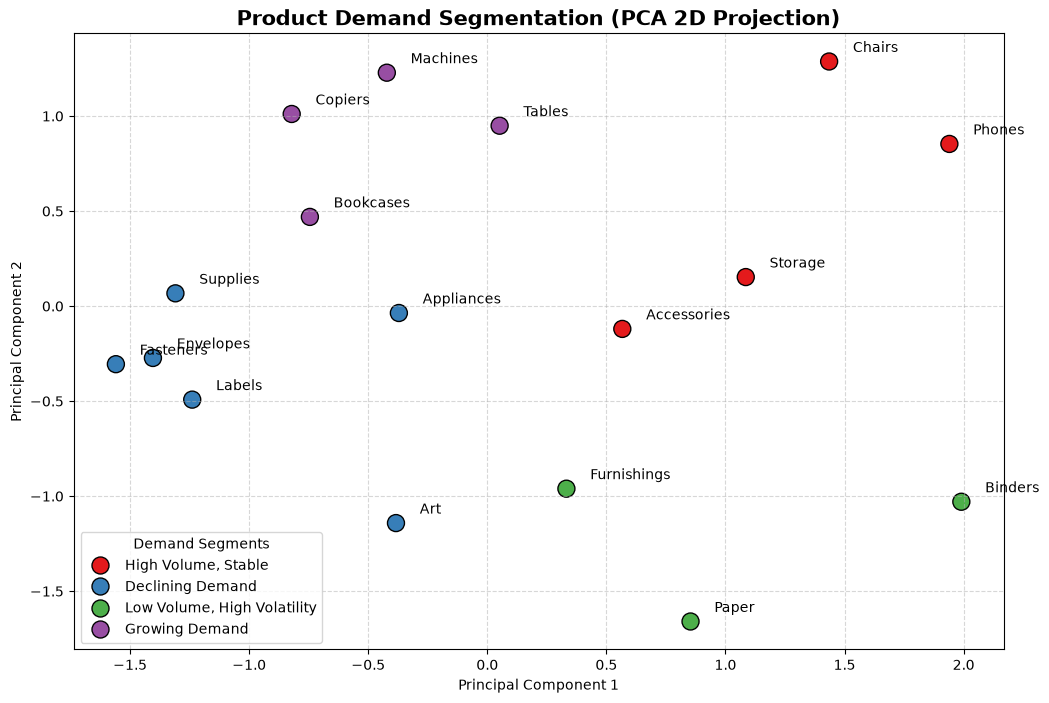

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

# --- 1. Dynamic Column Cleaning (Handles both spaces and hyphens) ---
# This converts 'Sub-Category' or 'Sub Category' directly into 'sub_category'
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# Print out your columns here to verify they look correct
print("Verified Cleaned Columns:", df.columns.tolist())

# --- Step 1: Extracting & Aggregating Features Safely ---
print("Step 1: Extracting & Aggregating Features...")

# A. Total Sales Volume (Now safely matching 'sub_category')
total_sales = df.groupby('sub_category')['sales'].sum()

# B. Average Order Value (AOV)
unique_orders = df.groupby('sub_category')['order_id'].nunique()

# C. Rebuild your feature aggregation dataframe
subcat_df = pd.DataFrame({
    'total_sales': total_sales,
    'unique_orders': unique_orders
})

print("Step 1 Complete: Features successfully grouped and extracted.")
print(subcat_df.head())

print("\nStep 2: Scaling Features for K-Means...")
scaler = StandardScaler()
scaled_data = scaler.fit_transform(subcat_df)

print("Step 3: Finding Optimal Clusters (Elbow Method)...")
inertia = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='darkblue')
plt.title('Elbow Method For Optimal k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("Elbow Method For Optimal k", dpi=300)
plt.show()

print("\nStep 4: Applying K-Means (k=4) & PCA for 2D Plotting...")
# 4 clusters map well to the business logic requested in the PDF
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
subcat_df['Cluster_ID'] = kmeans.fit_predict(scaled_data)

# Print Cluster Profiles to understand them
cluster_profiles = subcat_df.groupby('Cluster_ID').mean()
print("\n--- Cluster Mean Profiles ---")
print(cluster_profiles)

# Use PCA to reduce 4 features to 2 dimensions for the Scatter Plot
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled_data)
subcat_df['PCA1'] = pca_coords[:, 0]
subcat_df['PCA2'] = pca_coords[:, 1]

# Assign Business Labels based on cluster IDs (Modify dictionary if random_state changes output)
# Note: The manual mapping below is a generic safety net. Look at the means to verify.
cluster_names = {
    0: 'Growing Demand', 
    1: 'High Volume, Stable', 
    2: 'Declining Demand', 
    3: 'Low Volume, High Volatility'
}
subcat_df['Cluster_Label'] = subcat_df['Cluster_ID'].map(cluster_names)

# Final 2D Scatter Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_Label', data=subcat_df, palette='Set1', s=150, edgecolor='k')

# Add text labels for each Sub-Category
for item in subcat_df.index:
    plt.text(subcat_df.loc[item, 'PCA1'] + 0.1, 
             subcat_df.loc[item, 'PCA2'] + 0.05, 
             item, fontsize=10)

plt.title('Product Demand Segmentation (PCA 2D Projection)', fontsize=15, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Demand Segments')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("Product Demand Segmentation (PCA 2D Projection" , dpi=300)
plt.show()

##### Cluster Analysis & Stocking Strategy Recommendations
##### Based on the K-Means segmentation of sub-categories, here are the strategic recommendations for inventory and supply chain management:

##### 1. High Volume, Stable Demand (e.g., Phones, Chairs, Storage):
##### Profile: These products are the cash cows of the business. They generate massive revenue consistently and show predictable volatility.
##### Strategy (Just-in-Time / Safety Stock): Maintain high, automated replenishment cycles. Ensure safety stock is strictly monitored to prevent stockouts, as missing inventory here directly damages the top-line revenue. Negotiate long-term bulk contracts with suppliers.

##### 2. Growing Demand (High YoY Growth):
##### Profile: Products experiencing significant upward momentum compared to the previous year.
##### Strategy (Scale-Up): Increase procurement forecasting and allocate a larger marketing budget. Secure additional warehouse space for these items before peak seasons hit, ensuring the supply chain can handle the scaling volume without bottlenecks.

##### 3. Low Volume, High Volatility (e.g., Machines, Copiers):
##### Profile: Highly erratic sales behavior, often driven by rare, bulk B2B purchases or unexpected spikes. Low average frequency but sometimes very high Average Order Value (AOV).
##### Strategy (On-Demand / Drop-shipping): Do not hold massive inventory in warehouses, as it risks becoming dead stock. Move towards a drop-shipping model or negotiate rapid-fulfillment SLAs with suppliers so capital isn't tied up in unpredictable stock.

##### 4. Declining Demand:
##### Profile: Products showing negative YoY growth and shrinking total sales volume.
##### Strategy (Liquidation / Phase-out): Halt all automatic reordering. Implement aggressive discount campaigns and bundling strategies to liquidate existing stock. Reallocate the freed-up warehouse space to the 'Growing Demand' segments